Load modules

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import dragonfly
import h5py
from scipy.ndimage import gaussian_filter
from skimage.feature import peak_local_max
import matplotlib.patches as patches
plt.close('all')

Load reconstructed intensity from dragonfly

In [3]:
df_tag = 'detd_0002'
output_n = 'output_090.h5'

with h5py.File(f'./{df_tag}/data/{output_n}','r') as f:
    intens1 = f['/intens'][...]
intens1 = intens1.squeeze()

Set up detector

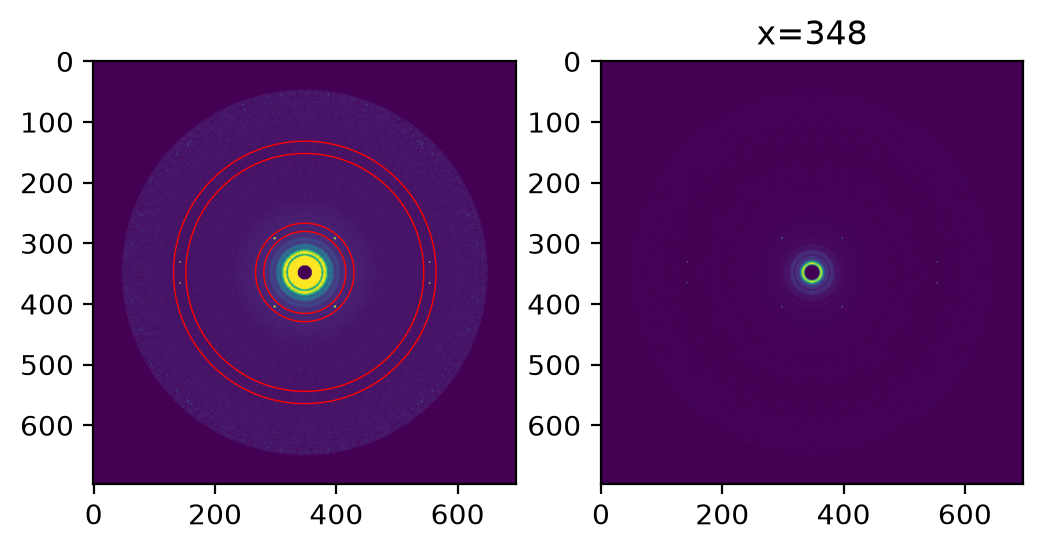

In [14]:
%matplotlib inline
det = dragonfly.Detector(fname=f'./{df_tag}/data/det.h5')

#qmax is in voxel units
q = np.linspace(-det.qmax(), det.qmax(), int(np.ceil(2*det.qmax())+3))

#3D volumes of qxyz
qx,qy,qz = np.meshgrid(q,q,q,)

#q magnitude
qqq = np.sqrt(qx**2 + qy**2 + qz**2)

#convert from voxels to reciprocal units A-1
lamb_a = 1.26
ewald_rad = 1070

dq = 1/(lamb_a*ewald_rad) 
qqq = qqq*dq

#2D detector q values
qq = np.sqrt( np.sum(det.qvals**2, axis=1))
qq = qq.reshape( (512,512) )*dq
#theta values on the detector
tt = np.arctan2( det.qvals[:,0], det.qvals[:,1]).reshape(512,512)

#remove the outer edge of the dragonfly recon
intens_crop = np.zeros(intens1.shape)
intens_crop[:] = intens1
intens_crop[qqq>(0.50*qqq.max())] = 0



#function to plot a slice of the dragonfly recon, with qbands for peak locations
def plot_slice(i):
    fig, ax = plt.subplots(1,2, figsize=(6,12), dpi=200)
    ax[0].imshow(intens_crop[i], clim=(0,1e-1))
    ax[1].imshow(intens_crop[i], clim=(0,intens_crop.max()))

    ax[0].contour(qqq[i], levels=[0.05,0.06, 0.145, 0.16], colors='red', linewidths=0.5)
    
    plt.title(f'x={i}')
    plt.show()
    #plt.close(fig)
             
#from ipywidgets import interact, IntSlider, FloatSlider,FloatText
#_ = interact(
#    plot_slice, 
#    i=IntSlider(min=0, max=intens_crop.shape[0] - 1, step=1, value=348, description='Slice:'),
#)

plot_slice(348)

Peaks are between q = 0.05-0.06 and q = 0.145-0.16. Now search through the hit images and find the intensities in this range

In [5]:
import glob

#load the h5 files
h5files = []
h5files += glob.glob('./hits/r0306_cp512-rb1/r*.h5')
h5files += glob.glob('./hits/r0307_cp512-rb1/r*.h5')


#intensity and theta values
i_qband1 = []
t_qband1 = []
i_qband2 = []
t_qband2 = []
q_qband1 = []
q_qband2 = []

qband1_loc = np.logical_and( qq>0.05, qq<0.06)
qband2_loc = np.logical_and( qq>0.145, qq<0.16)



#for each h5 file
for h5file in h5files:
    #load the file
    with h5py.File(h5file, 'r') as f:
        data =f['/data/'][:]

    #append the intensities and theta values within the q bands
    i_qband1.append(data[qband1_loc])
    t_qband1.append(tt[qband1_loc])
    q_qband1.append(qq[qband1_loc])
    
    i_qband2.append(data[qband2_loc])
    t_qband2.append(tt[qband2_loc])
    q_qband2.append(qq[qband2_loc])
    



Plot an example image of a hit with the qbands

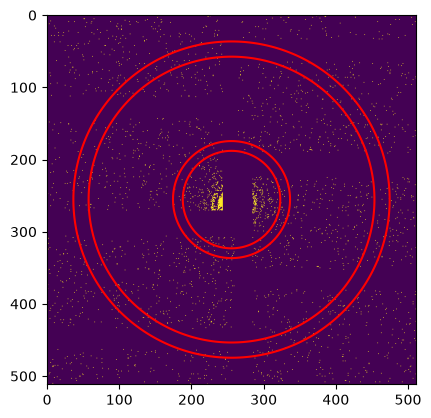

In [6]:
plt.imshow(data, clim=(0, 1e-3))
plt.contour(qq, levels=[0.05, 0.06], colors='red', linewidths=1.5)
plt.contour(qq, levels=[0.145, 0.16], colors='red', linewidths=1.5)

Plot a histogram of the intensities in each qband

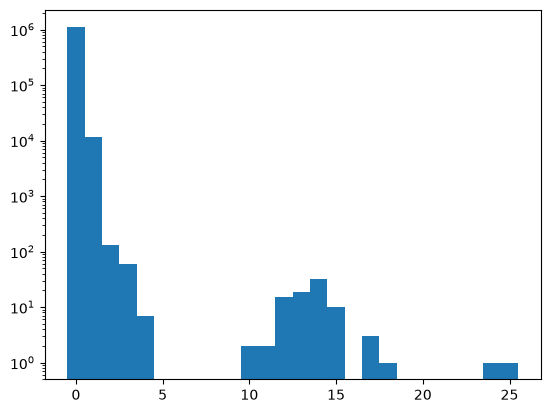

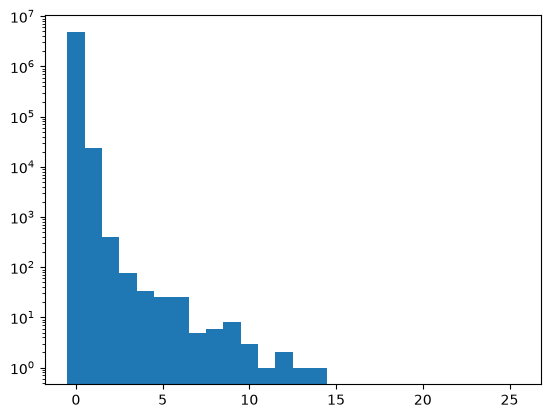

In [7]:
bins = np.arange(-0.5, 26, 1)
plt.hist(np.concatenate(i_qband1), bins=bins)
plt.yscale('log')
plt.figure()
plt.hist(np.concatenate(i_qband2), bins=bins)
plt.yscale('log')

Filter for high intenisties values. What theta and q values do they have?

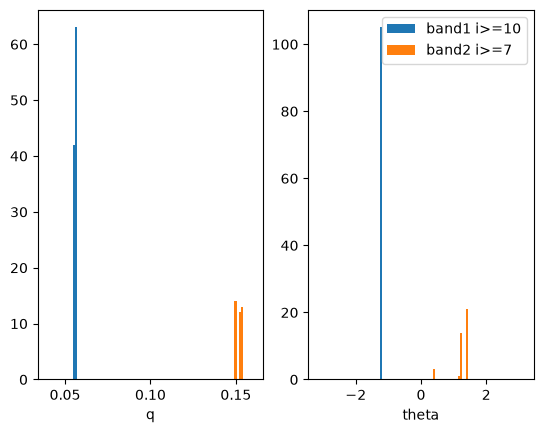

In [8]:
loc1 = np.where(np.array(i_qband1)>=10)
loc2 = np.where(np.array(i_qband2)>=7)



fig, ax = plt.subplots(1,2)
hist1 =ax[0].hist(np.array(q_qband1)[loc1], range=(0.04, 0.16), bins=100)
hist2 =ax[0].hist(np.array(q_qband2)[loc2], range=(0.04, 0.16), bins=100)
ax[0].set_xlabel('q')

hist1 =ax[1].hist(np.array(t_qband1)[loc1], range=(-np.pi, np.pi), bins=100, label='band1 i>=10')
hist2 =ax[1].hist(np.array(t_qband2)[loc2], range=(-np.pi, np.pi), bins=100, label='band2 i>=7')
ax[1].set_xlabel('theta')
plt.legend()

High intensity values appear at unique q and theta values. Find there position in the 512x512 image, then add them to the mask.

In [20]:
#print(np.array(q_qband1)[loc1])
#print(np.array(t_qband1)[loc1])

q_targets1 = np.asarray(q_qband1)[loc1]
t_targets1 = np.asarray(t_qband1)[loc1]
hotpix1 = np.isin(qq, q_targets1) & np.isin(tt, t_targets1)
print(np.where(hotpix1))

q_targets2 = np.asarray(q_qband2)[loc2]
t_targets2 = np.asarray(t_qband2)[loc2]
hotpix2 = np.isin(qq, q_targets2) & np.isin(tt, t_targets2)
print(np.where(hotpix2))

#print(np.where(hotpix1.flatten()))
#print(np.where(hotpix2.flatten()))

(array([184, 185, 185, 185, 186]), array([282, 281, 282, 283, 282]))
(array([342, 448, 449, 462, 463]), array([445, 324, 338, 286, 286]))


Plot the hotpixels 

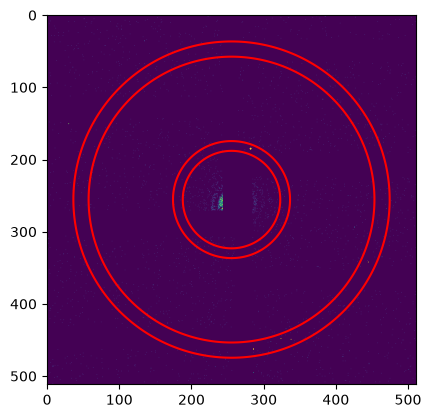

In [16]:
data[hotpix1] +=20
data[hotpix2] +=20
plt.imshow(data, clim=(0, 10))
plt.contour(qq, levels=[0.05, 0.06], colors='red', linewidths=1.5)
plt.contour(qq, levels=[0.145, 0.16], colors='red', linewidths=1.5)


In [21]:
assem_center = [657.61, 538.40]
crop_size = [512, 512]
xstart, xend = round(assem_center[1] - crop_size[1]//2), round(assem_center[1] + crop_size[1]//2)
ystart, yend = round(assem_center[0] - crop_size[0]//2), round(assem_center[0] + crop_size[0]//2)
        

In [26]:
ystart,xstart

(402, 282)